In [3]:
import torch
# import numpy as np

In [11]:
# import imageio
import matplotlib.pyplot as plt

In [ ]:
# import csv

In [ ]:
# import numpy as np

In [56]:
import torch.optim as optim
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F

# Download CIFAR10 (tranform applied for normalized tensor)

In [6]:
# training set
data_path = './data'
transform = transforms.Compose([transforms.ToTensor(),
              transforms.Normalize((0.5,0.5,0.5), (0.5, 0.5, 0.5))]) 

norm_cifar10 = datasets.CIFAR10(data_path, train=True, download=True,
transform=transform)
norm_cifar10_test = datasets.CIFAR10(data_path, train=False, download=True,
transform=transform)
# transforms.Normalize(mean, std)

Files already downloaded and verified
Files already downloaded and verified


In [7]:
print(len(norm_cifar10))
print (len(norm_cifar10_test))
# class names
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

50000
10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


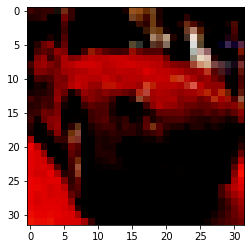

1

In [20]:
img_example, label=norm_cifar10[5]
plt.imshow(img_example.permute(1, 2, 0))      
# change dimension order to H,W,Channel
plt.show()
label

# Create sub datasets for only two classes: airplane and bird

In [21]:
# redefine labels: 0 (airplane), 2 (bird) --> 0 (airplane), 1(bird)
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
norm_cifar2 = [(img, label_map[label]) for img, label in norm_cifar10 if label in [0, 2]]
norm_cifar2_test = [(img, label_map[label]) for img, label in norm_cifar10_test if label in [0, 2]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


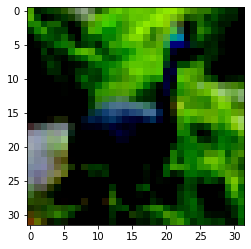

1


In [64]:
img, label=norm_cifar2[0]
# img shape:  torch.Size([3, 32, 32]), label: int
plt.imshow(img.permute(1, 2, 0))      
# change dimension order to H,W,Channel
plt.show()
print(label)

# Neural network by nn.Sequential()

In [65]:

model = nn.Sequential(
    nn.Linear(3072,25),
    nn.ReLU(),
    nn.Linear(25,12),
    nn.ReLU(),
    nn.Linear(12,2)
 )

In [66]:
img_batch = img.view(-1).unsqueeze(0) # shape torch.size [1,3072]

In [67]:
out=model(img_batch)
print(out)
print(out.shape)
#torch.tensor([label])

tensor([[-0.2294, -0.1383]], grad_fn=<AddmmBackward>)
torch.Size([1, 2])


In [68]:
loss_fn = nn.CrossEntropyLoss()

In [69]:
loss_fn(out, torch.tensor([label]))

tensor(0.6486, grad_fn=<NllLossBackward>)

In [52]:
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()


In [53]:
n_epochs = 3
for epoch in range(n_epochs):
    for img, label in norm_cifar2:
        out = model(img.view(-1).unsqueeze(0))
        # img: torch.Size([3,32,32])
        # img.view(-1): torch.Size([3072])
        # img.view(-1).unsqueeze(0): torch.Size([1,3072])
        # out: torch.Size([1,2])
        loss = loss_fn(out, torch.tensor([label]))
        # torch.tensor([label]) is the target index
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 2.432887
Epoch: 1, Loss: 1.794679
Epoch: 2, Loss: 2.303552


In [54]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
      
        #define layers with learnable parameters
        self.fc1 = nn.Linear(3 * 32 * 32, 25)
        self.fc2 = nn.Linear(25, 12)
        self.fc3 = nn.Linear(12,2)

    def forward(self, x):
        out = self.fc1(x)
        out = F.relu(out)         # function
        out = self.fc2(out) 
        out = F.relu(out)
        out = self.fc3(out)
        return out


In [57]:
import torch.optim as optim
import torch
import torch.nn as nn
train_loader = torch.utils.data.DataLoader(norm_cifar2, batch_size=64,shuffle=True)
# norm_cifar2: list[[tensor[3,32,32], label], [tensor[3,32,32], label],…]
'''
model = nn.Sequential(
    nn.Linear(3072,25),
    nn.ReLU(),
    nn.Linear(25,12),
    nn.ReLU(),
    nn.Linear(12,2)
 )
 '''
model=Net()
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
 
loss_fn = nn.CrossEntropyLoss()
n_epochs = 100
for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0] #64 for all, except 16 for the last batch, 10000/64=145.25 
        #print(labels.shape)
        outputs = model(imgs.view(batch_size, -1)) 
        # imgs.view(batch_size,-1): [64, 3072]
        # outputs: [64,2]
        loss = loss_fn(outputs, labels)
        # labels: [64]
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
     
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.536574
Epoch: 1, Loss: 0.464567
Epoch: 2, Loss: 0.370024
Epoch: 3, Loss: 0.658764
Epoch: 4, Loss: 0.745789
Epoch: 5, Loss: 0.497891
Epoch: 6, Loss: 0.318068
Epoch: 7, Loss: 0.264766
Epoch: 8, Loss: 0.285627
Epoch: 9, Loss: 0.445770
Epoch: 10, Loss: 0.252797
Epoch: 11, Loss: 0.293188
Epoch: 12, Loss: 0.382041
Epoch: 13, Loss: 0.307306
Epoch: 14, Loss: 0.286753
Epoch: 15, Loss: 0.184895
Epoch: 16, Loss: 0.535982
Epoch: 17, Loss: 0.216636
Epoch: 18, Loss: 0.469489
Epoch: 19, Loss: 0.390394
Epoch: 20, Loss: 0.115613
Epoch: 21, Loss: 0.181554
Epoch: 22, Loss: 0.496347
Epoch: 23, Loss: 0.122270
Epoch: 24, Loss: 0.185268
Epoch: 25, Loss: 0.311856
Epoch: 26, Loss: 0.204856
Epoch: 27, Loss: 0.320652
Epoch: 28, Loss: 0.362080
Epoch: 29, Loss: 0.353667
Epoch: 30, Loss: 0.252252
Epoch: 31, Loss: 0.054041
Epoch: 32, Loss: 0.256674
Epoch: 33, Loss: 0.130330
Epoch: 34, Loss: 0.396914
Epoch: 35, Loss: 0.163949
Epoch: 36, Loss: 0.112149
Epoch: 37, Loss: 0.202611
Epoch: 38, Loss: 0.114

In [58]:
batch_size

16

In [59]:
val_loader = torch.utils.data.DataLoader(norm_cifar2_test, batch_size=64,
shuffle=False)
correct = 0
total = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
     
        values, predicted = torch.max(outputs, dim=1) # return (values,indices)
        #print(predicted)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
print("Accuracy: %f" % (correct / total))

Accuracy: 0.837000


access parameters of trained model

In [60]:
model.parameters

<bound method Module.parameters of Net(
  (fc1): Linear(in_features=3072, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=12, bias=True)
  (fc3): Linear(in_features=12, out_features=2, bias=True)
)>

In [61]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print (name, param.data.shape, param.data)

fc1.weight torch.Size([25, 3072]) tensor([[-0.0218,  0.0143,  0.0299,  ..., -0.0100,  0.0021, -0.0318],
        [ 0.0179, -0.0087, -0.0062,  ..., -0.0185, -0.0052,  0.0175],
        [-0.0132,  0.0065,  0.0039,  ..., -0.0001,  0.0160,  0.0245],
        ...,
        [ 0.0142,  0.0046,  0.0125,  ..., -0.0021, -0.0017, -0.0189],
        [-0.0746, -0.0476, -0.0223,  ..., -0.0319, -0.0344, -0.0467],
        [ 0.0351,  0.0293,  0.0596,  ...,  0.0313,  0.0214,  0.0286]])
fc1.bias torch.Size([25]) tensor([-0.1133, -0.3298,  0.0149, -0.0664, -0.0061, -0.0296,  0.1450,  0.0835,
        -0.0717,  0.1005, -0.1379,  0.0118,  0.0539, -0.0537,  0.0149, -0.0957,
        -0.1795,  0.0066,  0.0760,  0.0478, -0.0827,  0.0366, -0.0590,  0.3149,
        -0.0629])
fc2.weight torch.Size([12, 25]) tensor([[ 3.3786e-01, -5.0286e-01, -9.6275e-03, -3.8294e-01,  4.7537e-01,
         -3.2478e-01, -5.8919e-01,  3.2045e-01, -1.4385e-01,  4.7774e-01,
         -1.7493e-02,  1.3584e-01,  2.9220e-01, -4.1593e-01,  3.3808

In [62]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list


(77163, [76800, 25, 300, 12, 24, 2])